In [1]:
import geopandas as gpd

#  Read training and validation data

train_val= gpd.read_file('train_val_data/train_val.shp')
train_val.head()

c:\Users\25193\anaconda3\envs\gis-vector\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
c:\Users\25193\anaconda3\envs\gis-vector\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect PROJ data files. Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()


,category,geometry
0,forest,POINT (29.05868 -2.42512)
1,tea,POINT (29.06158 -2.42884)
2,tea,POINT (29.06205 -2.42944)
3,tea,POINT (29.06232 -2.43084)
4,tea,POINT (29.06508 -2.43202)


In [21]:
import os

os.environ.pop("PROJ_LIB", None)
os.environ.pop("GDAL_DATA", None)

print("PROJ_LIB =", os.environ.get("PROJ_LIB"))
print("GDAL_DATA =", os.environ.get("GDAL_DATA"))

PROJ_LIB = None
GDAL_DATA = None


In [2]:
#  get unique number of categories
train_val['category'].unique()
#  shows four categories

<StringArray>
['forest', 'tea', 'other', 'water']
Length: 4, dtype: str

In [3]:
#  geometry types
print(train_val.geom_type.value_counts())

# display the bounds to check overlap with 
train_val.total_bounds

Point    800
Name: count, dtype: int64


array([29.0301703 , -2.47244663, 29.08007409, -2.3983599 ])

# check the coordinate reference system

In [4]:
train_val.crs

<Geographic 2D CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84" ...>
Name: WGS 84
Axis Info [ellipsoidal]:
- lon[east]: Longitude (Degree)
- lat[north]: Latitude (Degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# Visualize the vector geometries for better understanding

Text(298.76438826583546, 0.5, 'Latitude')

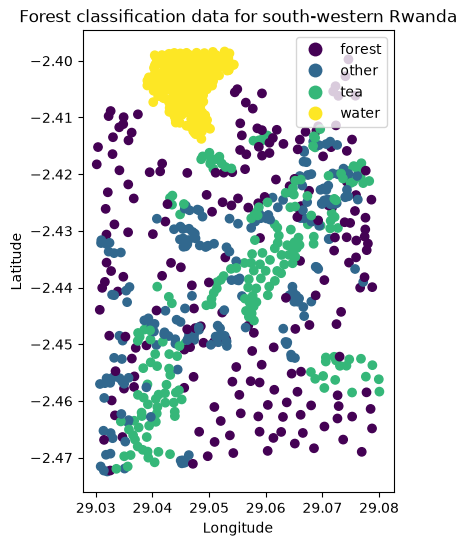

In [5]:
import matplotlib.pyplot as plt

train_val.plot(column="category",figsize=(10,6), cmap="viridis", legend=True)
plt.title("Forest classification data for south-western Rwanda")
plt.xlabel("Longitude")
plt.ylabel("Latitude")


From the visualization above it can be seen that the water bodies are more concentrated in the northern areas and tea and other bodies are distributed out in the geography

In [8]:
#  Load the raster data associated with area of interest and check crs 

import rioxarray as rxr

raster = rxr.open_rasterio("raster_data.tif")

print(raster)
print(raster.dims)
print(f"raster shape: {raster.shape}")
print(f"crs: {raster.rio.crs}")
print(f"bounds: {raster.rio.bounds()}")
train_val.total_bounds

<xarray.DataArray (band: 11, y: 881, x: 654)> Size: 51MB
[6337914 values with dtype=float64]
Coordinates:
  * band         (band) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * y            (y) float64 7kB -2.397 -2.397 -2.397 ... -2.476 -2.476 -2.476
  * x            (x) float64 5kB 29.03 29.03 29.03 29.03 ... 29.09 29.09 29.09
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4',...
('band', 'y', 'x')
raster shape: (11, 881, 654)
crs: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
bounds: (29.026632955055213, -2.4761162491470494, 29.08538277463663, -2.396974672616119)


array([29.0301703 , -2.47244663, 29.08007409, -2.3983599 ])

 The bounds and coordinate reference systems match for the vector and raster data allowing to extract information about categories to the raster and allow visualization

In [13]:
#  get attribute and band values for the raster data
print(raster.band.values)
print(raster.attrs)
import rasterio

with rasterio.open("raster_data.tif") as src:
    print(src.descriptions)

[ 1  2  3  4  5  6  7  8  9 10 11]
{'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': ('B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2')}
('B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2')


The red band= B4, green band= B3, Blue band= B2 based on sentinel information to visualize as image

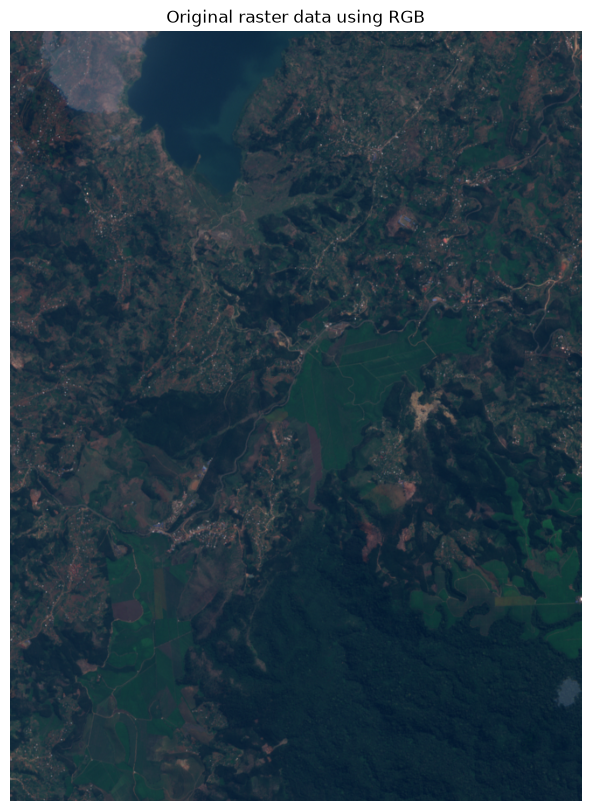

In [14]:
#  Visualize the raster data rgb values to understand the data better 

import numpy as np
import matplotlib.pyplot as plt

blue = raster.sel(band=11)
green = raster.sel(band=10)
red = raster.sel(band=9)

rgb = np.stack([
    red.values,
    green.values,
    blue.values
], axis=-1)

# Normalize to 0–1
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.axis("off")
plt.title("Original raster data using RGB")
plt.show()

# Extract pixel information from the vector data to get raster training data that is labeled with category information

In [18]:
import geopandas as gpd
import rasterio
import numpy as np


X = []
y = []

with rasterio.open("raster_data.tif") as src:

    # Make sure points and raster have the same CRS
    gdf = train_val.to_crs(src.crs)

    # Get coordinates of all points
    coordinates = [
        (point.x, point.y)
        for point in train_val.geometry
    ]

    # Extract raster values at each point
    samples = src.sample(coordinates)

    for sample, (_, row) in zip(samples, train_val.iterrows()):

        # sample contains one value per raster band
        sample = np.array(sample)

        # Skip NoData samples
        if src.nodata is not None:
            if np.any(sample == src.nodata):
                continue

        # Skip NaN/inf values
        if not np.isfinite(sample).all():
            continue

        X.append(sample)
        y.append(row["category"])

X = np.array(X)
y = np.array(y)

In [22]:
#  the above provides the pixels associated with geometries to use as training data 
print(X.shape) 
print(y.shape)

#  11 bands
#  1 category

(800, 11)
(800,)


We use a crossvalidation test on the validation to check for a simple model starting with logisitic regression and continuing with a robust random forest classifier that learns non-linear decision boundaries

Classes:
['forest' 'other' 'tea' 'water']


LOGISTIC REGRESSION

Accuracy: 0.91
Macro F1: 0.9100186954293464
Weighted F1: 0.9100186954293464

Classification Report:
              precision    recall  f1-score   support

      forest       0.97      0.97      0.97       200
       other       0.84      0.84      0.84       200
         tea       0.83      0.83      0.83       200
       water       1.00      0.99      1.00       200

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



RANDOM FOREST

Accuracy: 0.92125
Macro F1: 0.9212081931305631
Weighted F1: 0.921208193130563

Classification Report:
              precision    recall  f1-score   support

      forest       0.95      0.95      0.95       200
       other       0.84      0.89      0.87       200
         tea       0.90      0.84      0.87       200
       water       0.99      0.99      0.99       200

    accur

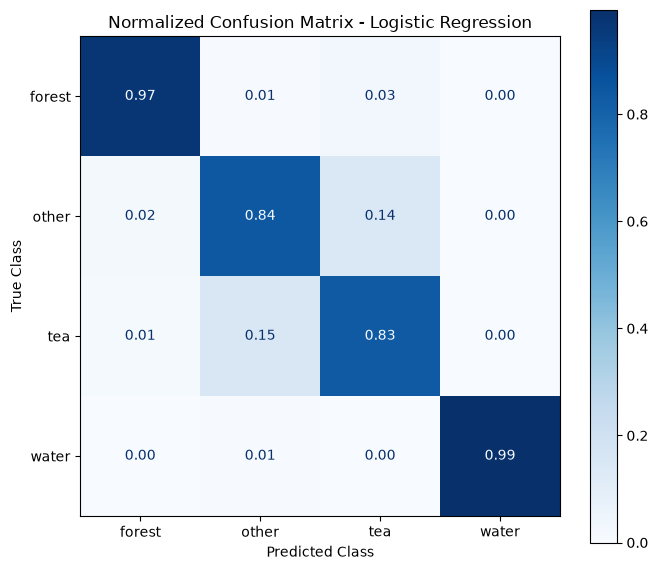

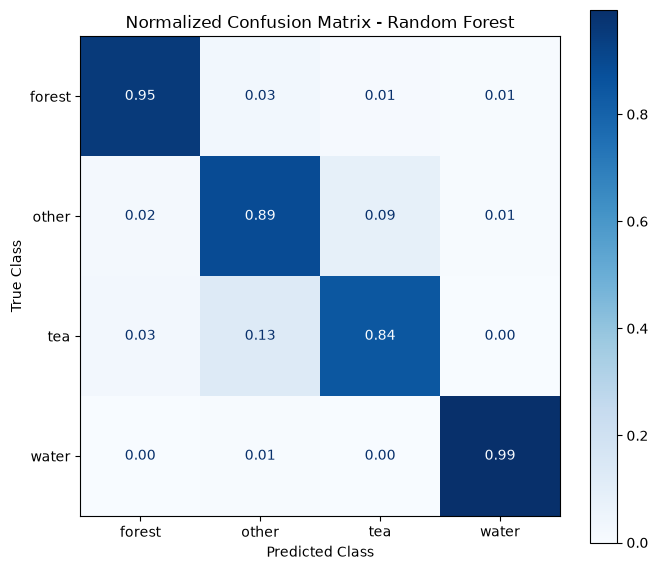



MODEL COMPARISON

Metric              Logistic Regression      Random Forest
-----------------------------------------------------------------
Accuracy            0.9100                   0.9213
Macro F1            0.9100                   0.9212
Weighted F1         0.9100                   0.9212


In [23]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Cross-validation strategy
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 2. Define models
# ============================================================

# Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])


# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 3. Generate cross-validated predictions
# ============================================================

logistic_pred = cross_val_predict(
    logistic_model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)


rf_pred = cross_val_predict(
    rf_model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)


# ============================================================
# 4. Get class labels
# ============================================================

classes = np.unique(y)

print("Classes:")
print(classes)


# ============================================================
# 5. Logistic Regression evaluation
# ============================================================

print("\n")
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print(
    "\nAccuracy:",
    accuracy_score(y, logistic_pred)
)

print(
    "Macro F1:",
    f1_score(
        y,
        logistic_pred,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        y,
        logistic_pred,
        average="weighted"
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y,
        logistic_pred,
        target_names=classes
    )
)


# ============================================================
# 6. Random Forest evaluation
# ============================================================

print("\n")
print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print(
    "\nAccuracy:",
    accuracy_score(y, rf_pred)
)

print(
    "Macro F1:",
    f1_score(
        y,
        rf_pred,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        y,
        rf_pred,
        average="weighted"
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y,
        rf_pred,
        target_names=classes
    )
)


# ============================================================
# 7. Normalized Confusion Matrix - Logistic Regression
# ============================================================

cm_logistic = confusion_matrix(
    y,
    logistic_pred,
    labels=classes,
    normalize="true"
)


disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(7, 6))

disp_logistic.plot(
    ax=ax,
    values_format=".2f",
    cmap="Blues"
)

ax.set_title(
    "Normalized Confusion Matrix - Logistic Regression"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

plt.tight_layout()
plt.show()


# ============================================================
# 8. Normalized Confusion Matrix - Random Forest
# ============================================================

cm_rf = confusion_matrix(
    y,
    rf_pred,
    labels=classes,
    normalize="true"
)


disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(7, 6))

disp_rf.plot(
    ax=ax,
    values_format=".2f",
    cmap="Blues"
)

ax.set_title(
    "Normalized Confusion Matrix - Random Forest"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Model comparison
# ============================================================

logistic_accuracy = accuracy_score(
    y,
    logistic_pred
)

rf_accuracy = accuracy_score(
    y,
    rf_pred
)

logistic_macro_f1 = f1_score(
    y,
    logistic_pred,
    average="macro"
)

rf_macro_f1 = f1_score(
    y,
    rf_pred,
    average="macro"
)

logistic_weighted_f1 = f1_score(
    y,
    logistic_pred,
    average="weighted"
)

rf_weighted_f1 = f1_score(
    y,
    rf_pred,
    average="weighted"
)


print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    f"\n{'Metric':<20}"
    f"{'Logistic Regression':<25}"
    f"{'Random Forest'}"
)

print("-" * 65)

print(
    f"{'Accuracy':<20}"
    f"{logistic_accuracy:<25.4f}"
    f"{rf_accuracy:.4f}"
)

print(
    f"{'Macro F1':<20}"
    f"{logistic_macro_f1:<25.4f}"
    f"{rf_macro_f1:.4f}"
)

print(
    f"{'Weighted F1':<20}"
    f"{logistic_weighted_f1:<25.4f}"
    f"{rf_weighted_f1:.4f}"
)

As can be seen the Random forest model enables a better accuracy in the cross validation test and the normalized confusion matrix is also given. This classifier can accurately predict 11 band pixel information with the correct category. The number of trees used for the random forest classifier is 300. The True positive and true negative outputs are also accurate enough as can be seen in the confusion matrix. 

Next step is to have a visualization of the sentinel image with the appropriate categories. We could overlay the RGB image data on to the polygon to access the category information and plot as the final result

Raster CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Number of bands: 11
Band descriptions: ('B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2')


C:\Users\25193\AppData\Local\Temp\ipykernel_25924\2760103166.py:26: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  red = src.read(9)
C:\Users\25193\AppData\Local\Temp\ipykernel_25924\2760103166.py:27: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  green = src.read(10)
C:\Users\25193\AppData\Local\Temp\ipykernel_25924\2760103166.py:28: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  blue = src.read(11)


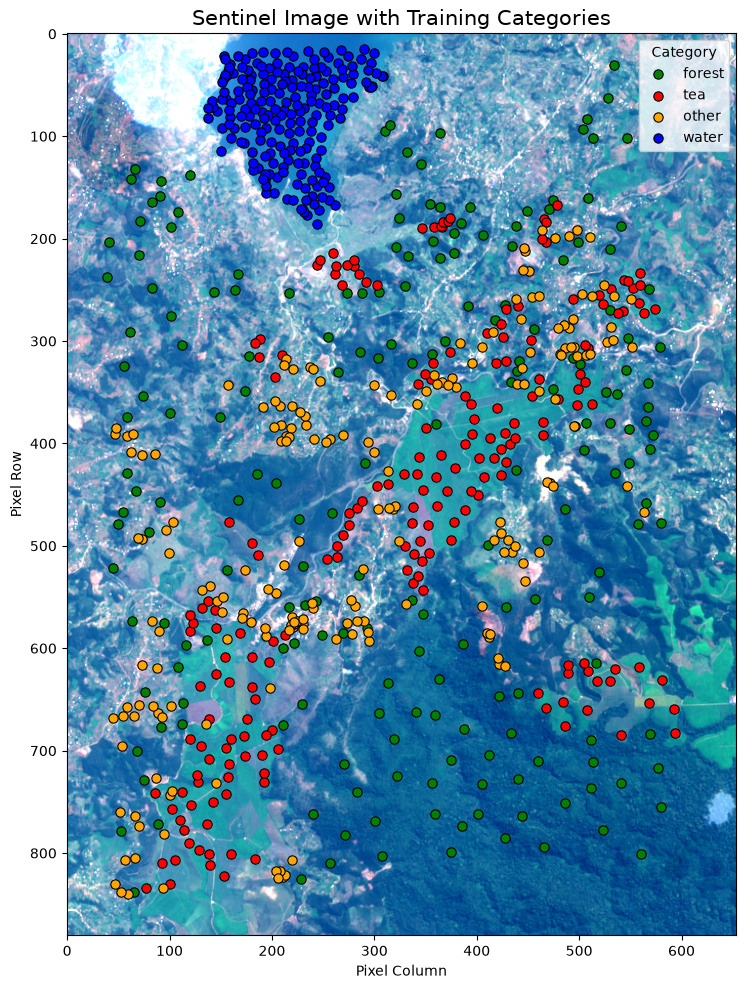

In [25]:


raster_path = "raster_data.tif"


# ============================================================
# 1. Open raster
# ============================================================

with rasterio.open(raster_path) as src:

    print("Raster CRS:", src.crs)
    print("Number of bands:", src.count)
    print("Band descriptions:", src.descriptions)

    # Make sure vector CRS matches raster CRS
    train_val = train_val.to_crs(src.crs)

    # ========================================================
    # 2. Read RGB bands
    # ========================================================

    # Your specified band mapping:
    # Red   = Band 9
    # Green = Band 10
    # Blue  = Band 11

    red = src.read(9)
    green = src.read(10)
    blue = src.read(11)

    # ========================================================
    # 3. Stack into RGB image
    # ========================================================

    rgb = np.stack(
        [red, green, blue],
        axis=-1
    ).astype(np.float32)


# ============================================================
# 4. Normalize RGB values for visualization
# ============================================================

lower = np.percentile(rgb, 2)
upper = np.percentile(rgb, 98)

rgb = np.clip(
    (rgb - lower) / (upper - lower),
    0,
    1
)


# ============================================================
# 5. Plot Sentinel image
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 10)
)

ax.imshow(rgb)


# ============================================================
# 6. Overlay categories
# ============================================================

# Create a fixed color for each category
category_colors = {
    "forest": "green",
    "tea": "red",
    "other": "orange",
    "water": "blue"
}


for category in train_val["category"].unique():

    subset = train_val[
        train_val["category"] == category
    ]

    # Convert point coordinates to raster row/column
    with rasterio.open(raster_path) as src:

        pixel_coords = [
            src.index(point.x, point.y)
            for point in subset.geometry
        ]

    rows = [r for r, c in pixel_coords]
    cols = [c for r, c in pixel_coords]

    ax.scatter(
        cols,
        rows,
        s=45,
        c=category_colors.get(category, "yellow"),
        label=category,
        edgecolor="black",
        linewidth=0.8
    )


# ============================================================
# 7. Formatting
# ============================================================

ax.set_title(
    "Sentinel Image with Training Categories",
    fontsize=15
)

ax.set_xlabel("Pixel Column")
ax.set_ylabel("Pixel Row")

ax.legend(
    title="Category",
    loc="upper right"
)

plt.tight_layout()
plt.show()